# Customer Intelligence Analysis and Prediction

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [4]:
import os
for dirname, _,filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [5]:
c_data=pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')
data_dict=pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv')

In [6]:
c_data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [7]:
data_dict

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


In [8]:
c_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [9]:
c_data.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


#### OBSERVATIONS
- The dataset contains 167 countries with 9 numerical and 1 categorical feature.
- No missing values are present, indicating that the dataset is complete.
- Income, GDP, and child mortality exhibit positive skewness, as their means are substantially higher than their medians.
- High standard deviations for income and GDP indicate considerable economic variation across countries.
- Several variables have large ranges, suggesting the presence of potential outliers.
- Inflation values include both negative (deflation) and extremely high positive values.
- Since feature scales vary significantly, StandardScaler will be applied before clustering.

In [10]:
c_data.duplicated().sum()

np.int64(0)

In [11]:
c_data.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [12]:
X=c_data.drop('country',axis=1)

In [13]:
c_data['country'].head()

0            Afghanistan
1                Albania
2                Algeria
3                 Angola
4    Antigua and Barbuda
Name: country, dtype: object

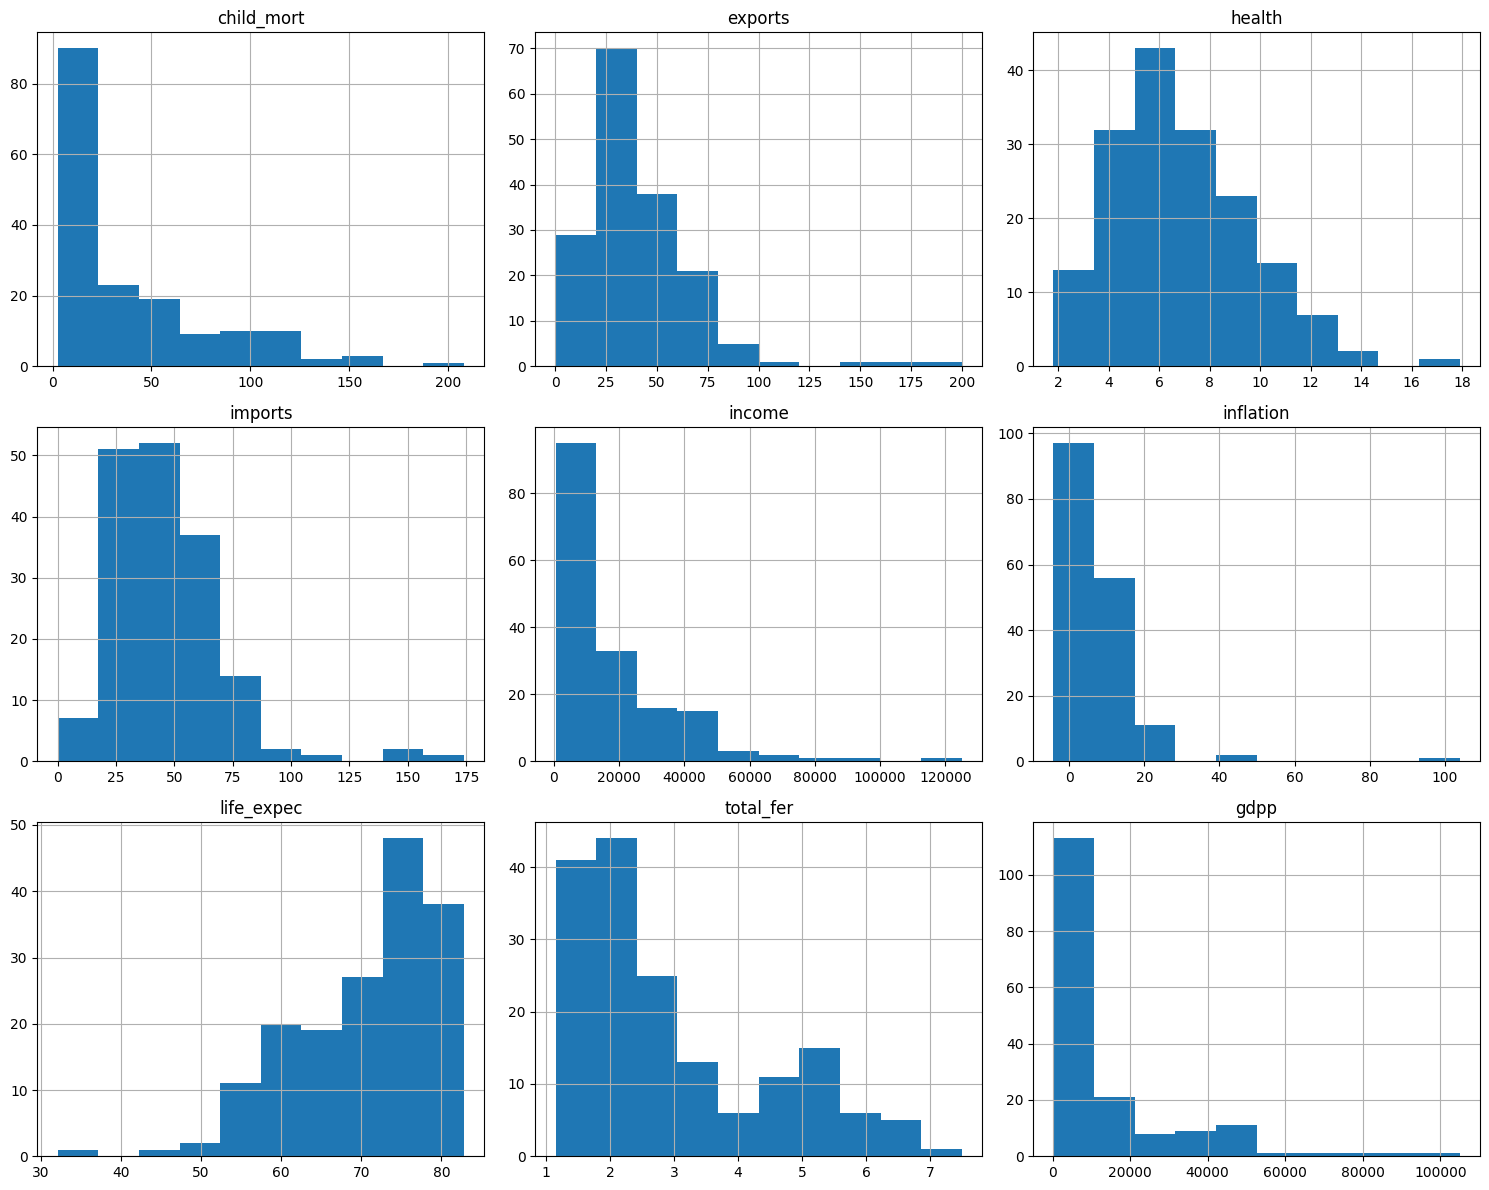

In [14]:
X.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

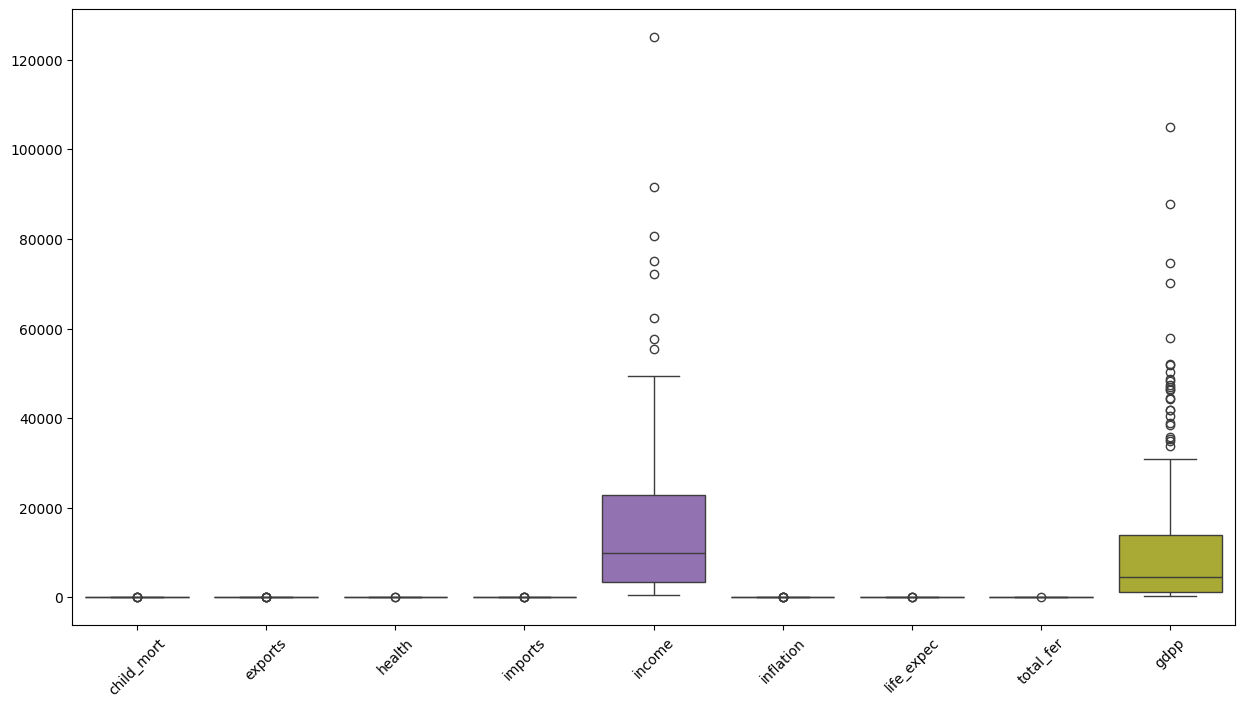

In [15]:
plt.figure(figsize=(15,8))
sns.boxplot(data=X)
plt.xticks(rotation=45)
plt.show()

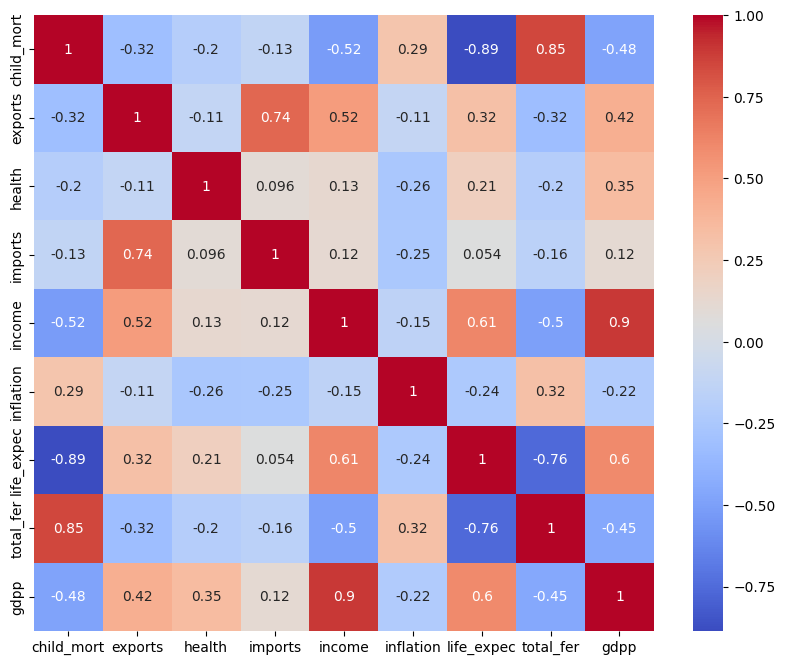

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):

    model = KMeans(n_clusters=k,
                   random_state=42)

    model.fit(X_scaled)

    wcss.append(model.inertia_)

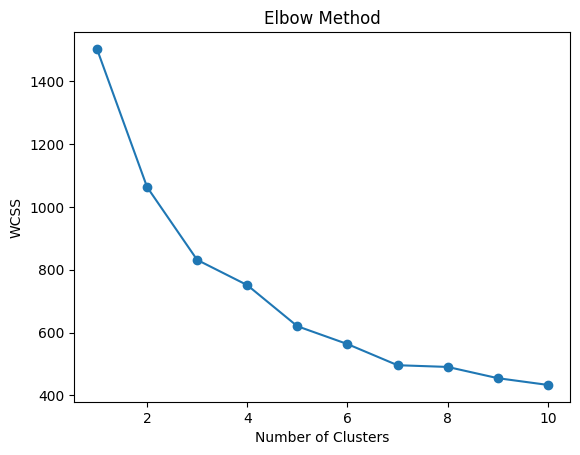

In [19]:
plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [20]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

c_data['Cluster'] = clusters

In [21]:
c_data.groupby('Cluster').mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


In [22]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    clusters
)

print(score)

0.285600988953231


In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

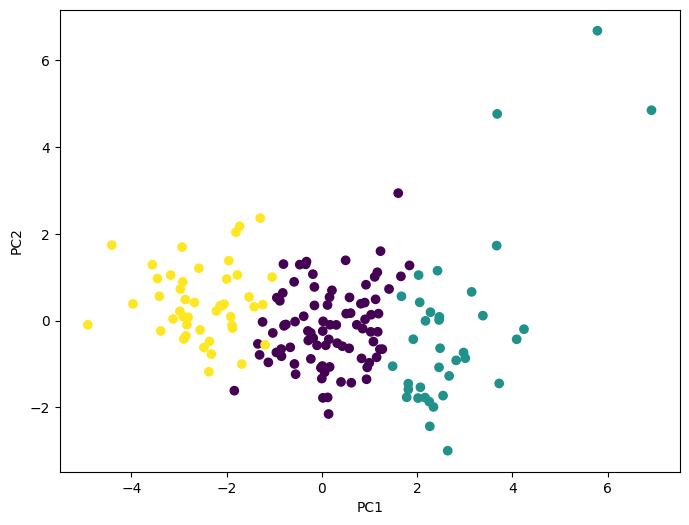

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

Cluster 0

Countries in Cluster 0 exhibit moderate income, GDP, life expectancy, and child mortality, indicating developing economies.

Cluster 1

Cluster 1 represents economically advanced countries with high income, high GDP, long life expectancy, and very low child mortality.

Cluster 2

Cluster 2 consists of economically weaker countries characterized by low GDP, low income, high child mortality, lower life expectancy, and higher fertility rates.

In [25]:
c_data[['country','Cluster']].sort_values('Cluster')

,country,Cluster
1,Albania,0
2,Algeria,0
5,Argentina,0
4,Antigua and Barbuda,0
6,Armenia,0
...,...,...
149,Timor-Leste,2
150,Togo,2
132,Sierra Leone,2
165,Yemen,2


In [26]:
for i in range(3):
    print(f"\nCluster {i}")
    print(c_data[c_data['Cluster']==i]['country'].tolist())


Cluster 0
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Cambodia', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Fiji', 'Georgia', 'Grenada', 'Guatemala', 'Guyana', 'Hungary', 'India', 'Indonesia', 'Iran', 'Iraq', 'Jamaica', 'Jordan', 'Kazakhstan', 'Kyrgyz Republic', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Macedonia, FYR', 'Malaysia', 'Maldives', 'Mauritius', 'Micronesia, Fed. Sts.', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'Myanmar', 'Nepal', 'Oman', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Romania', 'Russia', 'Samoa', 'Saudi Arabia', 'Serbia', 'Seychelles', 'Solomon Islands', 'Sri Lanka', 'St. Vincent and the Grenadines', 'Suriname', 'Tajikistan', 'Thailand', 'Tonga', 'Tunisia', 'Turkey', 'Tu

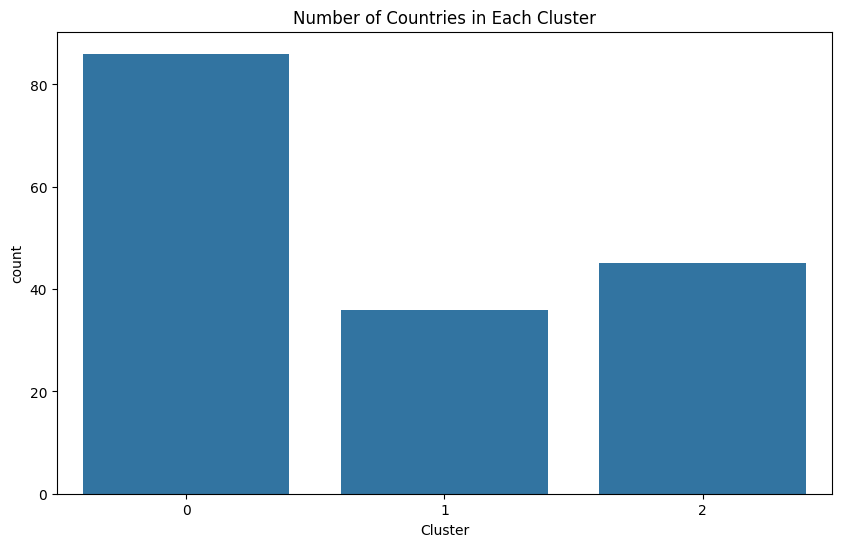

In [27]:
plt.figure(figsize=(10,6))
sns.countplot(x='Cluster', data=c_data)
plt.title("Number of Countries in Each Cluster")
plt.show()

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

print(scores)

{2: np.float64(0.2662961111870726), 3: np.float64(0.285600988953231), 4: np.float64(0.2880471307804802), 5: np.float64(0.30088229124112015), 6: np.float64(0.23565028812238528), 7: np.float64(0.2479313491087983), 8: np.float64(0.20198237114728412)}


In [29]:
for i in range(3):
    print(f"\nCluster {i}")
    print(c_data[c_data['Cluster'] == i]['country'].values)


Cluster 0
['Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Azerbaijan' 'Bahamas' 'Bangladesh' 'Barbados' 'Belarus' 'Belize'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil'
 'Bulgaria' 'Cambodia' 'Cape Verde' 'Chile' 'China' 'Colombia'
 'Costa Rica' 'Croatia' 'Dominican Republic' 'Ecuador' 'Egypt'
 'El Salvador' 'Estonia' 'Fiji' 'Georgia' 'Grenada' 'Guatemala' 'Guyana'
 'Hungary' 'India' 'Indonesia' 'Iran' 'Iraq' 'Jamaica' 'Jordan'
 'Kazakhstan' 'Kyrgyz Republic' 'Latvia' 'Lebanon' 'Libya' 'Lithuania'
 'Macedonia, FYR' 'Malaysia' 'Maldives' 'Mauritius'
 'Micronesia, Fed. Sts.' 'Moldova' 'Mongolia' 'Montenegro' 'Morocco'
 'Myanmar' 'Nepal' 'Oman' 'Panama' 'Paraguay' 'Peru' 'Philippines'
 'Poland' 'Romania' 'Russia' 'Samoa' 'Saudi Arabia' 'Serbia' 'Seychelles'
 'Solomon Islands' 'Sri Lanka' 'St. Vincent and the Grenadines' 'Suriname'
 'Tajikistan' 'Thailand' 'Tonga' 'Tunisia' 'Turkey' 'Turkmenistan'
 'Ukraine' 'Uruguay' 'Uzbekistan' 'Vanuatu' 'Venezuela

In [30]:
c_data['Cluster'].value_counts().sort_index()

Cluster
0    86
1    36
2    45
Name: count, dtype: int64

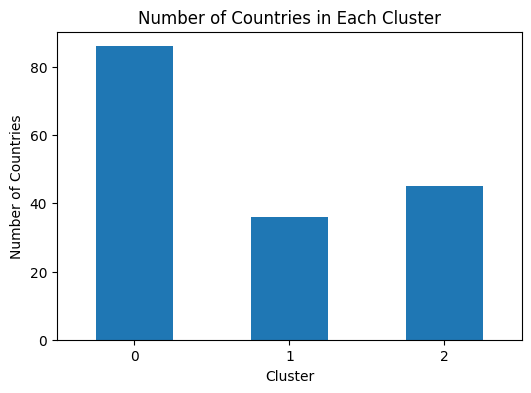

In [31]:
import matplotlib.pyplot as plt

cluster_counts = c_data['Cluster'].value_counts().sort_index()

plt.figure(figsize=(6,4))
cluster_counts.plot(kind='bar')

plt.title("Number of Countries in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Countries")

plt.xticks(rotation=0)
plt.show()

Cluster 0 contains the largest number of countries, representing developing economies. Cluster 1 contains the fewest countries and corresponds to highly developed nations, while Cluster 2 consists of underdeveloped countries with comparatively weaker socio-economic indicators.


In [32]:
from sklearn.cluster import DBSCAN

In [33]:
dbscan = DBSCAN(eps=1.2, min_samples=5)

db_labels = dbscan.fit_predict(X_scaled)

c_data['DBSCAN_Cluster'] = db_labels

In [34]:
print("Unique Clusters:", c_data['DBSCAN_Cluster'].unique())

Unique Clusters: [ 0  1 -1  2]


In [35]:
print("Number of Clusters:",
      len(set(db_labels)) - (1 if -1 in db_labels else 0))

Number of Clusters: 3


In [36]:
from sklearn.metrics import silhouette_score

if len(set(db_labels)) > 1:
    score = silhouette_score(X_scaled, db_labels)
    print(score)
else:
    print("Silhouette Score cannot be calculated.")

0.14844269545611685


In [37]:
for eps in [0.8,1,1.2,1.5,1.8,2]:
    
    db = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    n_noise = list(labels).count(-1)

    print(f"eps={eps}")
    print("Clusters:", n_clusters)
    print("Noise:", n_noise)
    print()

eps=0.8
Clusters: 3
Noise: 146

eps=1
Clusters: 3
Noise: 94

eps=1.2
Clusters: 3
Noise: 53

eps=1.5
Clusters: 1
Noise: 30

eps=1.8
Clusters: 1
Noise: 21

eps=2
Clusters: 1
Noise: 15



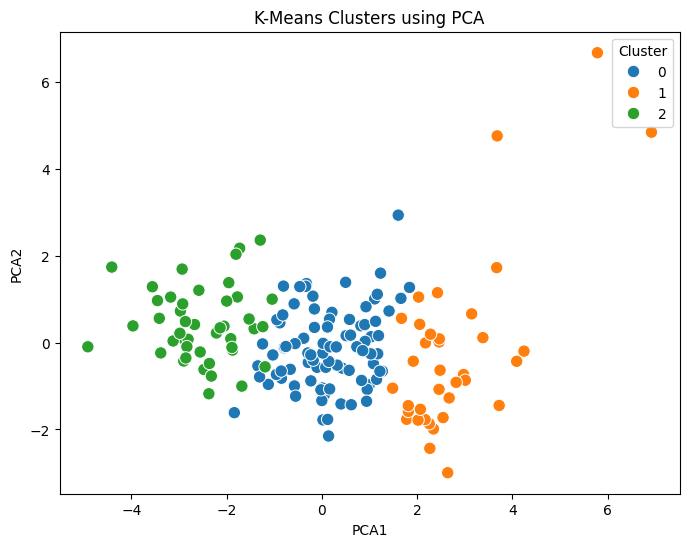

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'PCA1': X_pca[:,0],
    'PCA2': X_pca[:,1],
    'Cluster': c_data['Cluster']
})

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=viz,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='tab10',
    s=80
)

plt.title("K-Means Clusters using PCA")
plt.show()

In [39]:
c_data.groupby('Cluster').mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
Cluster,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,0.604651
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,0.777778
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,-0.488889


Insight 1

Cluster 1 represents developed countries with the highest average income, GDP per capita, and life expectancy, along with the lowest child mortality.

Insight 2

Cluster 2 consists of underdeveloped countries characterized by low income, low GDP, high child mortality, and high fertility rates.

Insight 3

Cluster 0 represents developing economies with moderate socio-economic indicators, lying between the developed and underdeveloped groups.

Insight 4

The K-Means algorithm successfully segmented countries into meaningful socio-economic groups despite a moderate silhouette score (~0.29), indicating some overlap in development characteristics.

Insight 5

DBSCAN identified several countries as noise depending on the eps value, demonstrating its ability to detect outliers that K-Means assigns to clusters.

In [40]:
c_data.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'Cluster',
       'DBSCAN_Cluster'],
      dtype='object')

### Customer Intelligence Layer

The K-Means algorithm segmented countries into three distinct socio-economic groups.

Instead of treating these cluster IDs as arbitrary numbers, we interpret them as market segments.

Cluster 0 → Developing Markets

Cluster 1 → Developed Markets

Cluster 2 → Underdeveloped Markets

These market segments will now be used as pseudo-labels for building a supervised learning model capable of predicting the segment of unseen countries.

In [41]:
cluster_names = {
    0: "Developing",
    1: "Developed",
    2: "Underdeveloped"
}

c_data["Market_Segment"] = c_data["Cluster"].map(cluster_names)

c_data[["country", "Cluster", "Market_Segment"]].head()

,country,Cluster,Market_Segment
0,Afghanistan,2,Underdeveloped
1,Albania,0,Developing
2,Algeria,0,Developing
3,Angola,2,Underdeveloped
4,Antigua and Barbuda,0,Developing


In [42]:
c_data["Market_Segment"].value_counts()

Market_Segment
Developing        86
Underdeveloped    45
Developed         36
Name: count, dtype: int64

In [43]:
segment_profile = c_data.groupby("Market_Segment").mean(numeric_only=True)

segment_profile.round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster
Market_Segment,,,,,,,,,,,
Developed,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44,1.0,0.78
Developing,22.46,40.27,6.25,47.36,12321.74,7.72,72.57,2.34,6461.77,0.0,0.60
Underdeveloped,95.11,28.60,6.30,42.31,3539.84,11.99,59.06,5.07,1766.71,2.0,-0.49


### Business Use Case 1 : Luxury Brand Expansion

Objective

Predict whether a country belongs to a developed, developing or underdeveloped market and recommend an expansion strategy.

Key Indicators

- Income
- GDP per capita
- Imports
- Life Expectancy

Business Decisions

Developed
→ Premium Stores

Developing
→ Entry Luxury

Underdeveloped
→ Delay Expansion

# Building the Customer Intelligence Model

The market segments generated through K-Means clustering are now treated as pseudo-labels. These labels represent different market categories (Developed, Developing, Underdeveloped).

A supervised learning model will now be trained to predict the market segment of unseen countries. This enables organizations to classify new markets and make strategic business decisions without rerunning the clustering algorithm.

In [44]:
# Features and Target

X = c_data.drop(
    columns=[
        'country',
        'Cluster',
        'DBSCAN_Cluster',
        'Market_Segment'
    ]
)

y = c_data['Market_Segment']

print(X.head())
print(y.head())

   child_mort  exports  health  imports  income  inflation  life_expec  \
0        90.2     10.0    7.58     44.9    1610       9.44        56.2   
1        16.6     28.0    6.55     48.6    9930       4.49        76.3   
2        27.3     38.4    4.17     31.4   12900      16.10        76.5   
3       119.0     62.3    2.85     42.9    5900      22.40        60.1   
4        10.3     45.5    6.03     58.9   19100       1.44        76.8   

   total_fer   gdpp  
0       5.82    553  
1       1.65   4090  
2       2.89   4460  
3       6.16   3530  
4       2.13  12200  
0    Underdeveloped
1        Developing
2        Developing
3    Underdeveloped
4        Developing
Name: Market_Segment, dtype: object


In [45]:
print("Features")

print(X.columns)

print()

print("Target")

print(y.unique())

Features
Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

Target
['Underdeveloped' 'Developing' 'Developed']


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (133, 9)
Testing samples: (34, 9)


In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [48]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
y_pred = rf.predict(X_test)

y_pred

array(['Developing', 'Developing', 'Developing', 'Developing',
       'Underdeveloped', 'Underdeveloped', 'Underdeveloped', 'Developing',
       'Developed', 'Developed', 'Developing', 'Developing',
       'Underdeveloped', 'Developing', 'Developing', 'Developing',
       'Developed', 'Underdeveloped', 'Developing', 'Underdeveloped',
       'Underdeveloped', 'Developed', 'Developed', 'Developed',
       'Developing', 'Developing', 'Developing', 'Underdeveloped',
       'Developing', 'Developing', 'Developed', 'Developed',
       'Underdeveloped', 'Developing'], dtype=object)

In [50]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.97


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

     Developed       0.88      1.00      0.93         7
    Developing       1.00      0.94      0.97        18
Underdeveloped       1.00      1.00      1.00         9

      accuracy                           0.97        34
     macro avg       0.96      0.98      0.97        34
  weighted avg       0.97      0.97      0.97        34



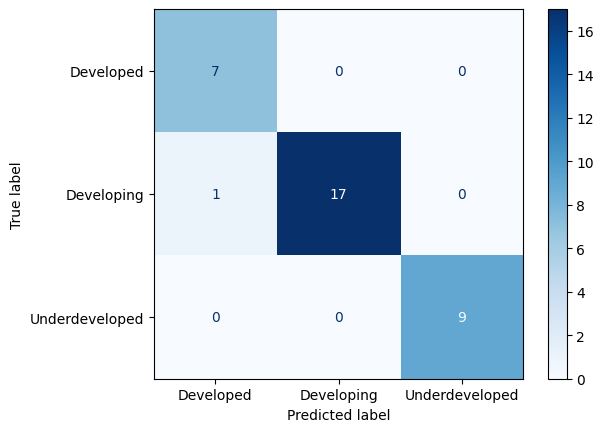

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.show()

In [53]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.266699
8,gdpp,0.228246
7,total_fer,0.173101
6,life_expec,0.145349
4,income,0.130083
2,health,0.019174
5,inflation,0.016391
3,imports,0.010657
1,exports,0.010300


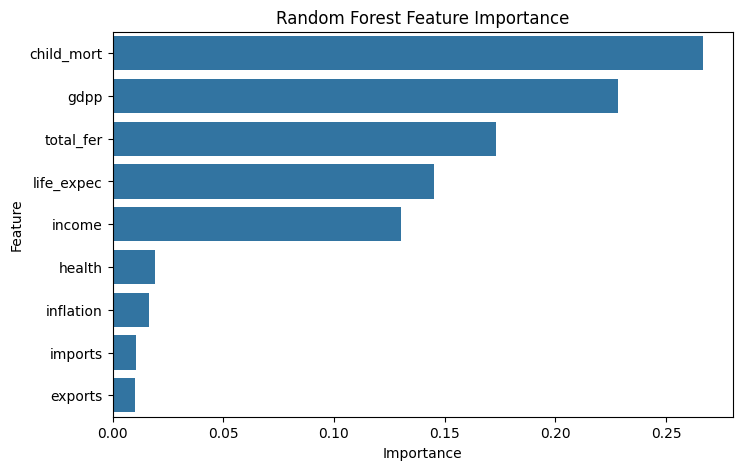

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")
plt.show()

# Business Intelligence & Use Cases

The trained Random Forest model predicts the market segment of unseen countries using socio-economic indicators. Based on the predicted market segment, organizations from different industries can make informed expansion and investment decisions.

Possible applications include:

1. Food Industry
2. Banking & Financial Services
3. Real Estate
4. Luxury Brands

In [55]:
industry_recommendations = {

    "Developed": {
        "Food": "Launch premium and health-focused products.",
        "Bank": "Offer investment banking, wealth management and premium credit cards.",
        "Property": "Invest in luxury residential and commercial projects.",
        "Luxury": "Open flagship stores and launch premium collections."
    },

    "Developing": {
        "Food": "Focus on affordable packaged foods and family packs.",
        "Bank": "Offer home loans, SME financing and insurance.",
        "Property": "Develop affordable housing and mixed-use projects.",
        "Luxury": "Introduce entry-level luxury products through selected stores."
    },

    "Underdeveloped": {
        "Food": "Focus on low-cost nutrition and essential food products.",
        "Bank": "Promote microfinance and financial inclusion.",
        "Property": "Prioritize infrastructure and government-backed housing.",
        "Luxury": "Avoid large-scale expansion and use online distribution."
    }
}

In [58]:
predicted_segment = y_pred[0]

print("Predicted Market Segment:", predicted_segment)

print("\nBusiness Recommendations:\n")

for industry, recommendation in industry_recommendations[predicted_segment].items():
    print(f"{industry}: {recommendation}")

Predicted Market Segment: Developing

Business Recommendations:

Food: Focus on affordable packaged foods and family packs.
Bank: Offer home loans, SME financing and insurance.
Property: Develop affordable housing and mixed-use projects.
Luxury: Introduce entry-level luxury products through selected stores.
